# Experimentation with model

### Imports

In [1]:
import sys
sys.path.append("src")  
from src.llama_activate import (
    get_pipe,
    run_simulation,
    retrieve_existing_net,
)
import src.utils.visualization as vis
import src.utils.metrics as metrics
import src.utils.reading_in as ri
import argparse

c:\Users\chris\Documents\courses\Thesis\Project\own_setup\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True


### Set variables

In [6]:
# Variables
rounds = 1
num_agents = 300
net = "sda"
seed = 53
alpha = 0.5
m = 2
degree = 3
p = 0.3
depressed = False
enforce_ngrams = False
use_existing_net = False
states = ["depressed", "enforce_ngrams", "basis"]
k = 0
pipe = get_pipe()
dim = 2

args = argparse.Namespace(
        net=net,
        rounds=rounds,
        num_agents=num_agents,
        seed=seed,
        m=m,
        p=p,
        k=k,
        depressed=depressed,
        enforce_ngrams=enforce_ngrams,
        alpha=alpha,
        degree = degree,
        dim = dim,
    )

Device set to use cuda:0


### Generate network and run simulation

In [7]:

networks = []
running_fracs_nets = []
fracs_dist_step_nets = []

# retrieve existing networks with different states
if use_existing_net:
    for state in states:
        args.enforce_ngrams = (state == "enforce_ngrams")
        args.depressed = (state == "depressed")
        file_path = retrieve_existing_net(args)

        # reload network from saved properties
        network, running_fracs, fracs_dist_step= ri.generate_network(file_path, pipe)
        networks.append(network)
        running_fracs_nets.append(running_fracs)
        fracs_dist_step_nets.append(fracs_dist_step)
else:
    network, tweet_history, running_fracs, fracs_dist_step = run_simulation(
        net=net,
        rounds=rounds,
        num_agents=num_agents,
        seed=seed,
        m=m,
        p=p,
        k=k,
        depressed=depressed,
        enforce_ngrams=enforce_ngrams,
        pipe=pipe,
        degree=degree, 
        alpha=alpha,
        dim = dim
    )
    networks.append(network)

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
GENERATOR:  (inputs: Optional[torch.Tensor] = None, generation_config: Optional[transformers.generation.configuration_utils.GenerationConfig] = None, logits_processor: Optional[transformers.generation.logits_process.LogitsProcessorList] = None, stopping_criteria: Optional[transformers.generation.stopping_criteria.StoppingCriteriaList] = None, prefix_allowed_tokens_fn: Optional[Callable[[int, torch.Tensor], list[int]]] = None, synced_gpus: Optional[bool] = None, assistant_model: Optional[ForwardRef('PreTrainedModel')] = None, streamer: Optional[ForwardRef('BaseStreamer')] = None, negative_prompt_ids: Optional[torch.Tensor] = None, negative_prompt_attention_mask: Optional[torch.Tensor] = None, use_model_defaults: Optional[bool] = None, custom_generate: Union[str, Callable, NoneType] = None, **kwargs) -> Union[transformers.generation.utils.GenerateDecoderOnlyOutput, transformers.generation.utils.GenerateEncoderDecoderOutp

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Agent 200 FORCED TWEET OUTPUT: TWEET: Time for a beach day
Agent 35 FORCED TWEET OUTPUT: TWEET: Just spent the weekend in nature and I'm feeling refreshed
Agent 132 FORCED TWEET OUTPUT: TWEET: I'm a curious person who loves trying new foods in Tokyo!
Agent 23 FORCED TWEET OUTPUT: TWEET: Just spent 4 hours planning my outfits for the week
Agent 271 FORCED TWEET OUTPUT: TWEET: 
I just spent 24 hours lost in a foreign city, trying to find my place, but all I found was myself #lost #explore
Agent 238 FORCED TWEET OUTPUT: TWEET: "Why do some people find happiness when they're not happy? The more they have, the more elusive it becomes." #mentalhealthmatters
Agent 298 FORCED TWEET OUTPUT: TWEET:
I'm lost in a sea of 6G and social media noise
Agent 47 FORCED TWEET OUTPUT: TWEET: Just had the craziest dream about a talking pineapple pizza 🍕😂
Agent 225 FORCED TWEET OUTPUT: TWEET: "What's the one thing that always makes you feel most alive?"
Agent 46 FORCED TWEET OUTPUT: TWEET:
"Just had my first

#### Generate PCA plots

In [4]:
# plot TF-IDF PCA
n_grams = metrics.load_ngrams_tsv("data/distorted_language_ngrams.tsv")
global_tf_idf, _, _ = metrics.retrieve_tf_idf(networks, num_steps=100, shift=5, n_grams=n_grams)
pca_runs = metrics.reduce_dimensionality(global_tf_idf, n_components=2)
vis.plot_tf_idf_PCA(pca_runs, states, num_steps=100, shift=5)

ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

#### Generate plots concerning distorted info

Plotting results for network with state: depressed


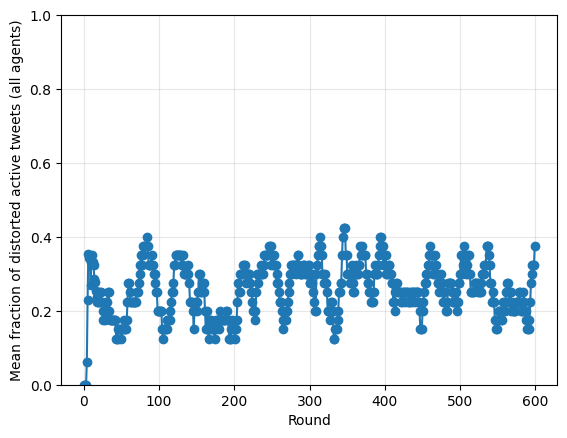

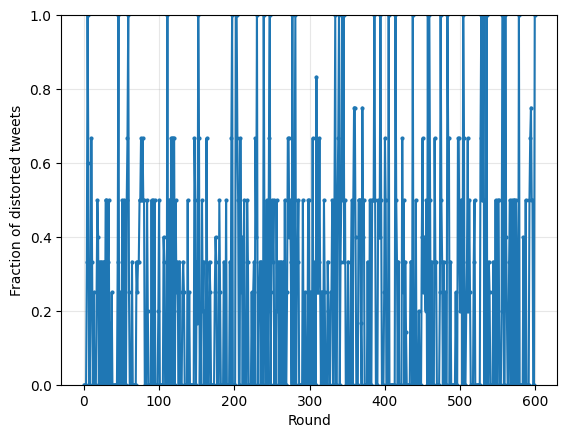

Plotting results for network with state: enforce_ngrams


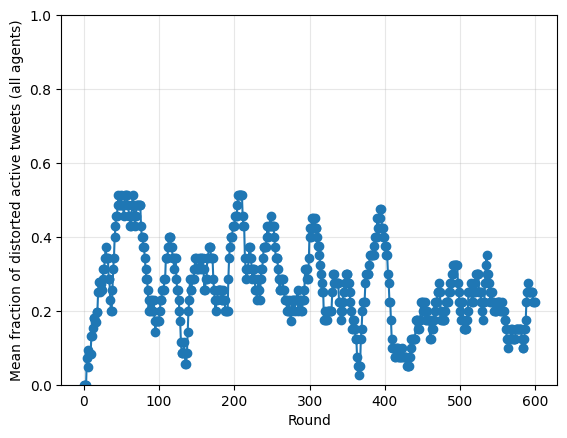

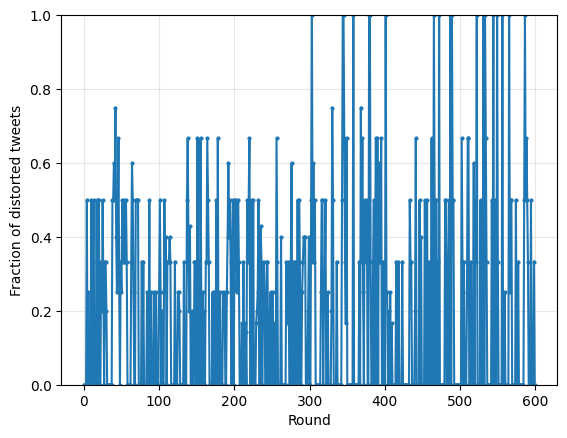

Plotting results for network with state: basis


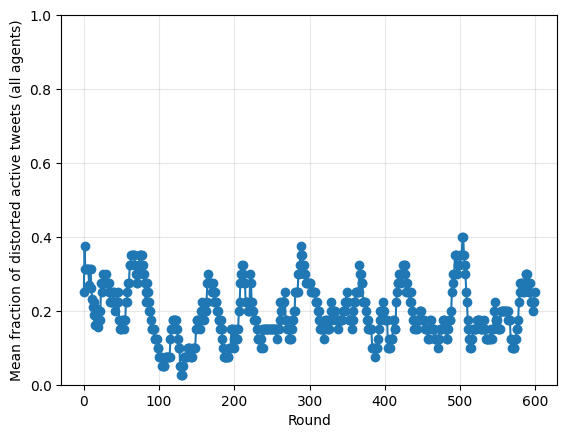

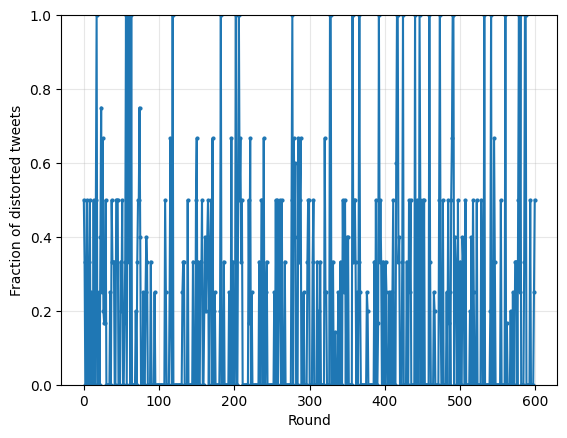

In [ ]:
for i, network in enumerate(networks):

    print(f"Plotting results for network with state: {states[i]}")
    vis.plot_running_fracs(
        running_fracs_nets[i],
        network.m if hasattr(network, "m") else 0,
        network.p if hasattr(network, "p") else 0.0,
        enforced_ngrams=(states[i] == "enforce_ngrams"),
        depressed=(states[i] == "depressed"),
        type_nn=net,
    )
    vis.plot_distorted_fracs(
        fracs_dist_step_nets[i],
        network.m if hasattr(network, "m") else 0,
        network.p if hasattr(network, "p") else 0.0,
        enforced_ngrams=(states[i] == "enforce_ngrams"),
        depressed=(states[i] == "depressed"),
        type_nn=net,
    )


### activation plot

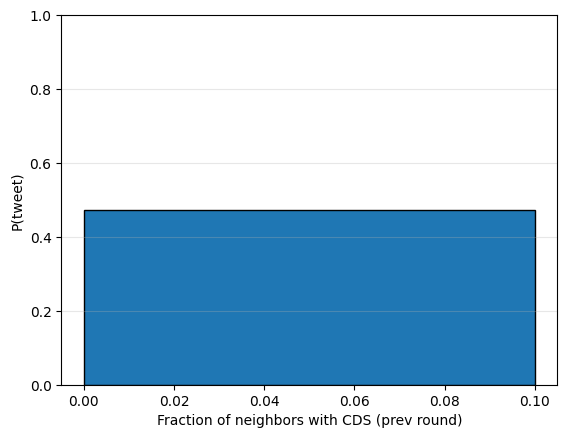

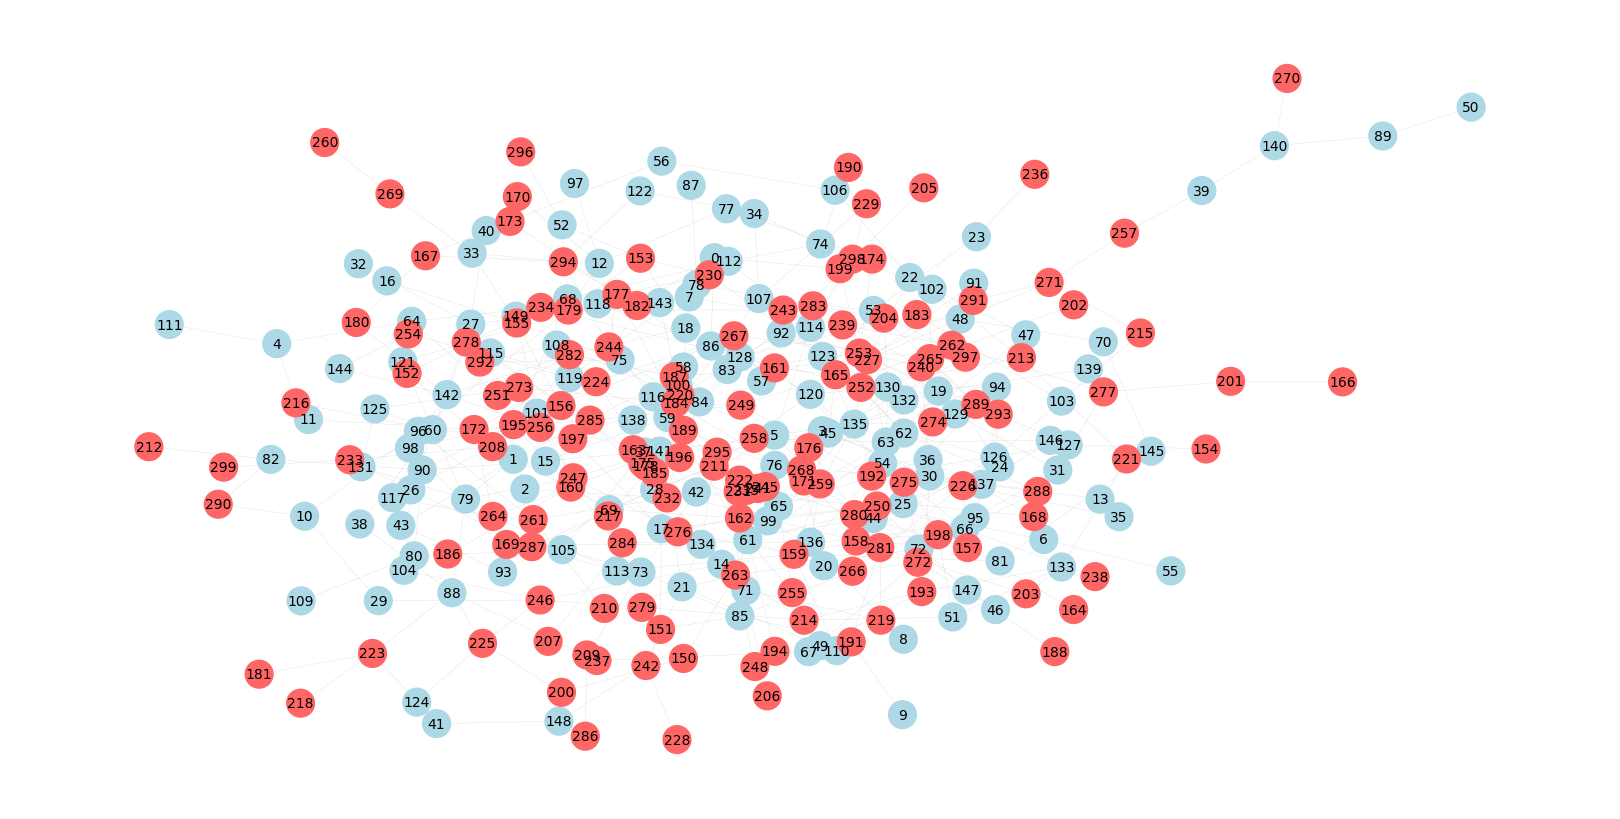

In [8]:
vis.distorted_info(network.cds_info)
vis.print_network(network)
